# ✍ Clase de espacios duales y tensores  🐻

> Paola Andrea Ríos Campos - 2240684 Grupo B1



### ***Bibliotecas***

In [19]:
import sympy as sp
from sympy import init_printing
from IPython.display import display, Math

# Sección 3.1.4 Ejercicio 7

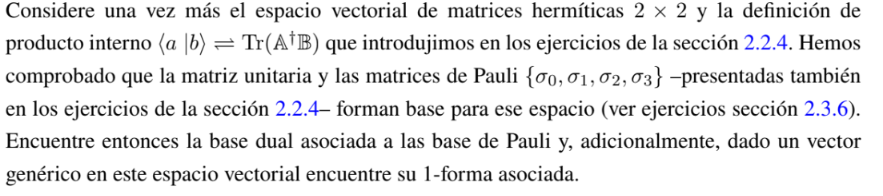

In [20]:
#Estilo
init_printing(use_unicode=True)

# Defino las matrices de Pauli
o_0 = sp.eye(2)
o_1 = sp.Matrix([[0, 1], [1, 0]])
o_2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
o_3 = sp.Matrix([[1, 0], [0, -1]])

basis = [o_0, o_1, o_2, o_3]  # Base de matrices de Pauli

# Producto interno Hilbert–Schmidt: <A,B> = Tr(A^dagger B)
def hs_inner(A, B):
    return sp.simplify((A.H * B).trace())

# Construcción de la matriz de Gram
n = len(basis)
G = sp.Matrix([[hs_inner(basis[i], basis[j]) for j in range(n)] for i in range(n)])
G = sp.simplify(G)

# Inversa de Gram
G_inv = sp.simplify(G.inv())

# Calculamos la base dual: e^i = sum_j (G^{-1})_{ij} e_j
dual_basis = []
for i in range(n):
    dual_i = sp.zeros(2)
    for j in range(n):
        dual_i += G_inv[i, j] * basis[j]
    dual_basis.append(sp.simplify(dual_i))

# ---------- Salidas bonitas en Jupyter (LaTeX) ----------
display(Math(r"\textbf{Matriz de Gram: } \mathbf{G} = " + sp.latex(G)))
display(Math(r"\textbf{Inversa de Gram: } \mathbf{G}^{-1} = " + sp.latex(G_inv)))

# Mostrar las bases duales con índice y su matriz (LaTeX)
for i, db in enumerate(dual_basis):
    display(Math(r"e^{%d} \;=\; %s" % (i, sp.latex(db))))

# Verificación: ⟨e^i, e_j⟩ = δ^i_j
check = sp.Matrix([[hs_inner(dual_basis[i], basis[j]) for j in range(n)] for i in range(n)])
display(Math(r"\text{Verificación } \langle e^i, e_j\rangle = " + sp.latex(check)))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Sección 3.3.5 Ejercicio 1

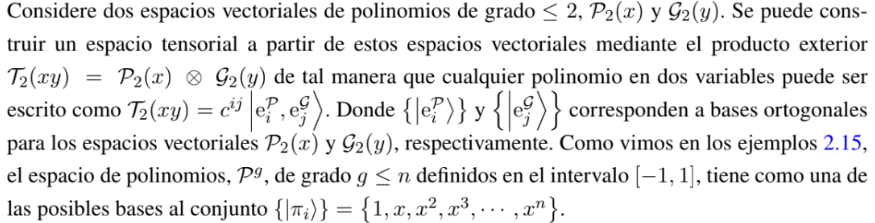

## ***Punto a)***

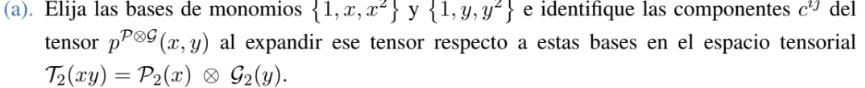

#####*Código*

In [21]:
# Defino x y y
x, y = sp.symbols('x y')

# Defino bases de P y G
P2_x = [1, x, x**2]  # Base de P2(x)
G2_y = [1, y, y**2]  # Base de G2(y)

# Crear el espacio tensorial como matriz
tensor_matrix = []

# Lleno la matriz con el producto tensorial
for p in P2_x:
    row = []
    for g in G2_y:
        row.append(sp.simplify(p * g))
    tensor_matrix.append(row)

# Convertir a una matriz de sympy
tensor_matrix = sp.Matrix(tensor_matrix)

# Mostrar la matriz resultante
print("Matriz que corresponde a la base del producto tensorial entre los espacios P(x) y G(x)")
display(Math(r"\mathbf{C} = " + sp.latex(tensor_matrix)))

#Ahora si la quiero expandida
print("Base expandida:")
tensor = []

# Llenamos el tensor combinando las bases de P2(x) y G2(y)
for p in P2_x:
    for g in G2_y:
        tensor.append(sp.simplify(p * g))

# Mostrar los productos del tensor como una sola fila

display(sp.Matrix([[elem for elem in tensor]]))

Matriz que corresponde a la base del producto tensorial entre los espacios P(x) y G(x)


<IPython.core.display.Math object>

Base expandida:


⎡       2             2   2   2     2  2⎤
⎣1  y  y   x  x⋅y  x⋅y   x   x ⋅y  x ⋅y ⎦

## ***Punto b)***

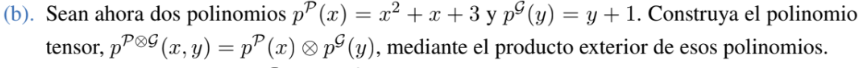

#####*Código*

In [22]:
# Definir las variables
x, y = sp.symbols('x y')

# Definir las nuevas bases
P = [1, x, x**2]  # Base de p^P(x)
G = [1, y]        # Base de p^G(y)

# Crear el espacio tensorial como lista de productos
tensor = []

# Llenamos el tensor combinando las bases de p^P(x) y p^G(y)
for p in P:
    for g in G:
        tensor.append(sp.simplify(p * g))

# Convertir la lista en una matriz 3x2 (dimensión de las bases)
tensor_matrix = sp.Matrix(3, 2, tensor)

# Mostrar la matriz resultante
print("Matriz de los coeficientes del producto tensorial:")
display(Math(r"\mathbf{C} = " + sp.latex(tensor_matrix)))

#Para mostrarlo expandido
print("Base expandida:")
tensor = []

# Llenamos el tensor combinando las bases de P2(x) y G2(y)
for p in P:
    for g in G:
        tensor.append(sp.simplify(p * g))

# Mostrar los productos del tensor como una sola fila

display(sp.Matrix([[elem for elem in tensor]]))


Matriz de los coeficientes del producto tensorial:


<IPython.core.display.Math object>

Base expandida:


⎡               2   2  ⎤
⎣1  y  x  x⋅y  x   x ⋅y⎦

## ***Punto c)***

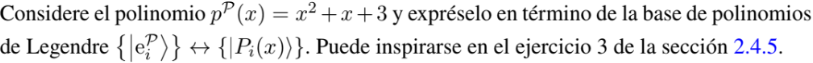

#####*Código*

In [23]:
# Definir las variables
x = sp.symbols('x')

# Polinomio pP(x)
pP = x**2 + x + 3

# Polinomios de Legendre P0(x), P1(x) y P2(x)
P0 = 1
P1 = x
P2 = (3*x**2 - 1)/2

# Calcular los productos internos definidos como integrales (del espacio de los polinomios de Legendre)
inner_P0 = sp.integrate(pP * P0, (x, -1, 1))
inner_P1 = sp.integrate(pP * P1, (x, -1, 1))
inner_P2 = sp.integrate(pP * P2, (x, -1, 1))

# Calcular los productos internos de los polinomios de Legendre
norm_P0 = sp.integrate(P0 * P0, (x, -1, 1))
norm_P1 = sp.integrate(P1 * P1, (x, -1, 1))
norm_P2 = sp.integrate(P2 * P2, (x, -1, 1))

# Calcular los coeficientes c0, c1, c2
c0 = inner_P0 / norm_P0
c1 = inner_P1 / norm_P1
c2 = inner_P2 / norm_P2

cij= sp.Matrix([[c0,c1,c2]])
print("Coeficientes del polinomio escrito en el producto de los polinomios de Legendre:")

display(Math(r"\mathbf{C} = " + sp.latex(cij)))

Coeficientes del polinomio escrito en el producto de los polinomios de Legendre:


<IPython.core.display.Math object>

## ***Punto d)***


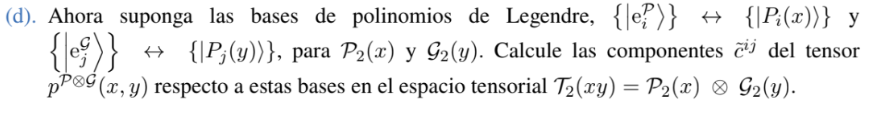

##### *Código*

In [24]:
# variables
x, y = sp.symbols('x y')

# polinomios de Legendre P2(x) y G2(y)
P0_x = 1
P1_x = x
P2_x = (3*x**2 - 1)/2

G0_y = 1
G1_y = y
G2_y = (3*y**2 - 1)/2

# un polinomio general p^(P⊗G)(x, y)
p_PG = x**2 + 3*x*y + y**2  # ejemplo

# Calcular los productos internos entre p^(P⊗G)(x, y) y los polinomios de Legendre
# Coeficientes c_ij, usando integrales
c00 = sp.integrate(sp.integrate(p_PG * P0_x * G0_y, (x, -1, 1)), (y, -1, 1))
c01 = sp.integrate(sp.integrate(p_PG * P0_x * G1_y, (x, -1, 1)), (y, -1, 1))
c02 = sp.integrate(sp.integrate(p_PG * P0_x * G2_y, (x, -1, 1)), (y, -1, 1))

c10 = sp.integrate(sp.integrate(p_PG * P1_x * G0_y, (x, -1, 1)), (y, -1, 1))
c11 = sp.integrate(sp.integrate(p_PG * P1_x * G1_y, (x, -1, 1)), (y, -1, 1))
c12 = sp.integrate(sp.integrate(p_PG * P1_x * G2_y, (x, -1, 1)), (y, -1, 1))

c20 = sp.integrate(sp.integrate(p_PG * P2_x * G0_y, (x, -1, 1)), (y, -1, 1))
c21 = sp.integrate(sp.integrate(p_PG * P2_x * G1_y, (x, -1, 1)), (y, -1, 1))
c22 = sp.integrate(sp.integrate(p_PG * P2_x * G2_y, (x, -1, 1)), (y, -1, 1))

# matriz de coeficientes c_ij
tensor_matrix = sp.Matrix([[c00, c01, c02],
                           [c10, c11, c12],
                           [c20, c21, c22]])

print("Matriz de coeficientes c_ij de un polinomio general respecto al producto tensorial de las bases de polinomios de Legendre")
display(Math(r"\mathbf{C} = " + sp.latex(tensor_matrix)))

Matriz de coeficientes c_ij de un polinomio general respecto al producto tensorial de las bases de polinomios de Legendre


<IPython.core.display.Math object>